# Sum of squares
---
<img src='https://www.janestreet.com/puzzles/niedermaier1.png' width=700 align='center'/>




Place a digit in each of the 25 spots in the below 5×5 grid, so that each 5-digit number (leading zeroes are ok) reading across and reading down is divisible by the number outside the grid, trying to maximize the sum of the 25 numbers you enter. An example of a completed grid with sum 100 is presented on the right.

Please submit your answer (along with any other comments you want to provide) as an ordered pair of your sum, and your 25 numbers, reading left to right, top to bottom.

Example submission: (100,1623552460048932486847030)

In [1]:
import time
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
from z3 import *

Visualisation
--
We create a little plotting function that gives outputs similar to the visualisations from the puzzle. It's tested with the example given.

In [2]:
def grid_plotter(array: np.array, x_list: np.array, y_list: np.array) -> None:
    ax = sns.heatmap(
        array, cmap=ListedColormap(['whitesmoke']), annot=True, annot_kws={"fontsize":20, "color":"blue"}, cbar=False, linewidths=3, linecolor="white",
        xticklabels=x_list, yticklabels=y_list
    )
    ax.tick_params(axis="both", length=0, rotation=0, labelsize=16, colors="lightgrey")
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
    plt.figure(figsize = (8,8))
    plt.show()

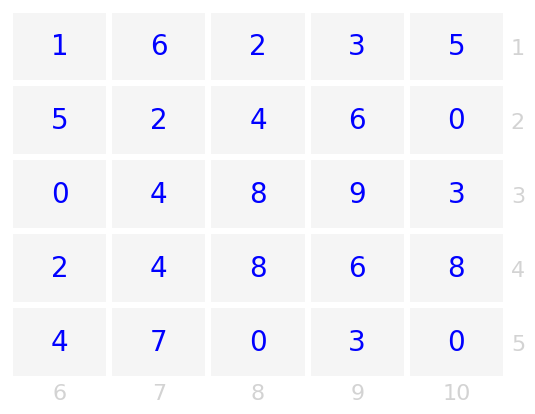

<Figure size 800x800 with 0 Axes>

In [3]:
grid = np.array([1, 6, 2, 3, 5, 5, 2, 4, 6, 0, 0, 4, 8, 9, 3, 2, 4, 8, 6, 8, 4, 7, 0, 3, 0])
grid = grid.reshape((5,5))
x_axis = [6, 7, 8, 9, 10]
y_axis = [1, 2, 3, 4, 5]

grid_plotter(grid, x_axis, y_axis)

Solving
--
Solved using z3, in short it assings values to each grid cell that meets the division criteria and maximises for the sum.

In [4]:
start = time.perf_counter()

grid = np.array([Int(f"X_{i}") for i in range(25)])
o = Optimize()
total = Sum(list(grid))
o.maximize(total)

for e in grid:
    o.add(e < 10, e > -1)

grid = grid.reshape(5,5)

for idx, row in enumerate(grid):
    e = Sum([row[i] * 10 ** (5 - i - 1) for i in range(5)])
    o.add(e % y_axis[idx] == 0)

for idx, row in enumerate(grid.T):
    e = Sum([row[i] * 10 ** (5 - i - 1) for i in range(5)])
    o.add(e % x_axis[idx] == 0)


if o.check() == sat:
    m = o.model()
    sol = np.array([[m[cell].as_long() for cell in row] for row in grid])
    print(sol)

end = time.perf_counter()

print(f"Time elapsed is {(end - start):.2f} seconds")

[[9 8 9 9 9]
 [9 9 9 9 8]
 [7 9 8 9 9]
 [9 9 8 9 6]
 [8 9 8 9 0]]
Time elapsed is 11.20 seconds


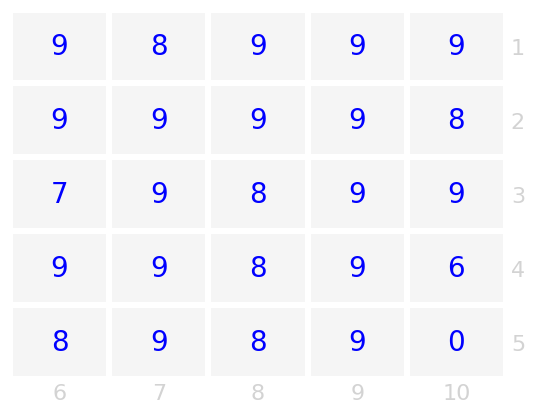

<Figure size 800x800 with 0 Axes>

SOLUTION: total digit sum is 205


In [5]:
grid_plotter(np.array(sol), x_axis, y_axis)
print(f"SOLUTION: total digit sum is {sum(sol.flatten())}")